In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
video_path = r"C:\\Users\\USER\\Desktop\\5th Semester\\Robotics Self\\OpenCV\\videos\\Twodots.mp4"
video = cv2.VideoCapture(video_path) # Using this I open the video. This give access to the video frame by frame

### First here I am trying only for one frame

In [27]:
ret, frame = video.read()
if not ret:
    print("Could not read frame")
else:
    height, width = frame.shape[:2]

    image_center_x = width // 2
    image_center_y = height // 2

### Here ret is a boolean value and it tells whether successfully got a frame or not. frame is the actual image.

In [28]:
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
print(hsv.shape)

(398, 674, 3)


### Why HSV ?
In a real video, the red object might have different brightness or lighting  
So we can define a range of Hue values corresponding to red, while allowing some variation in brightness and saturation  
Hue-color, S-Purity, V-Brightness  

In [29]:
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 100, 100])
upper_red2 = np.array([180, 255, 255])

### Here it says Keep the pixels whose HSV values fall inside the above range. Because here I try to detect red dot.
Here two ranges for red is because OpenCV represents red around both ends of the Hue scale

In [5]:
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask = mask1 | mask2 # This means if the pixels are detected in either masks it becomes white

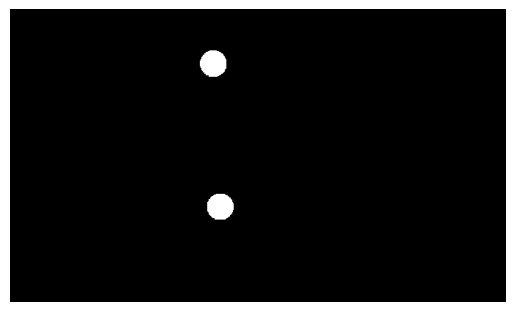

In [6]:
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

In [7]:
contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

Number of contours: 2


Here cv2.RETR_EXTERNAL means Only find the outermost contours.

In [8]:
if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea) # Here only for this particular video the larget object was considered
    area = cv2.contourArea(largest_contour)
    print("Largest contour area:", area)

Largest contour area: 983.5


In [9]:
max(contours, key=cv2.contourArea)

array([[[271,  56]],

       [[270,  57]],

       [[269,  57]],

       [[268,  58]],

       [[266,  58]],

       [[266,  59]],

       [[265,  60]],

       [[264,  60]],

       [[264,  61]],

       [[263,  62]],

       [[262,  62]],

       [[262,  63]],

       [[260,  65]],

       [[260,  67]],

       [[259,  68]],

       [[259,  69]],

       [[258,  70]],

       [[258,  77]],

       [[259,  78]],

       [[259,  79]],

       [[260,  80]],

       [[260,  82]],

       [[262,  84]],

       [[262,  85]],

       [[263,  85]],

       [[264,  86]],

       [[264,  87]],

       [[265,  87]],

       [[266,  88]],

       [[266,  89]],

       [[269,  89]],

       [[270,  90]],

       [[270,  91]],

       [[281,  91]],

       [[282,  90]],

       [[283,  90]],

       [[284,  89]],

       [[285,  89]],

       [[287,  87]],

       [[288,  87]],

       [[291,  84]],

       [[291,  82]],

       [[293,  80]],

       [[293,  68]],

       [[292,  67]],

       [[2

In [10]:
x, y, w, h = cv2.boundingRect(largest_contour)  # This creates a rectangle around the object.

print("x =", x)
print("y =", y)
print("width =", w)
print("height =", h)

x = 258
y = 56
width = 36
height = 36


### The Following finds the middle of the bounding box. 


In [30]:
center_x = x + w // 2
center_y = y + h // 2

print("Object center:", center_x, center_y)

Object center: 134 152


In [31]:
cv2.rectangle(frame,(x, y),(x + w, y + h),(0, 255, 0),2)

array([[[244, 244, 244],
        [244, 244, 244],
        [244, 244, 244],
        ...,
        [244, 241, 242],
        [246, 241, 242],
        [247, 242, 243]],

       [[244, 244, 244],
        [244, 244, 244],
        [244, 244, 244],
        ...,
        [244, 241, 242],
        [246, 241, 242],
        [247, 242, 243]],

       [[244, 244, 244],
        [244, 244, 244],
        [244, 244, 244],
        ...,
        [244, 241, 242],
        [246, 241, 242],
        [247, 242, 243]],

       ...,

       [[247, 242, 243],
        [247, 242, 243],
        [247, 242, 243],
        ...,
        [243, 240, 239],
        [244, 241, 240],
        [244, 241, 240]],

       [[247, 242, 243],
        [247, 242, 243],
        [247, 242, 243],
        ...,
        [243, 240, 239],
        [244, 241, 240],
        [244, 241, 240]],

       [[247, 242, 243],
        [247, 242, 243],
        [247, 242, 243],
        ...,
        [243, 240, 239],
        [244, 241, 240],
        [244, 241, 240]]

In [32]:
cv2.circle(frame,(center_x, center_y), 5, (0, 0, 255), -1)

array([[[244, 244, 244],
        [244, 244, 244],
        [244, 244, 244],
        ...,
        [244, 241, 242],
        [246, 241, 242],
        [247, 242, 243]],

       [[244, 244, 244],
        [244, 244, 244],
        [244, 244, 244],
        ...,
        [244, 241, 242],
        [246, 241, 242],
        [247, 242, 243]],

       [[244, 244, 244],
        [244, 244, 244],
        [244, 244, 244],
        ...,
        [244, 241, 242],
        [246, 241, 242],
        [247, 242, 243]],

       ...,

       [[247, 242, 243],
        [247, 242, 243],
        [247, 242, 243],
        ...,
        [243, 240, 239],
        [244, 241, 240],
        [244, 241, 240]],

       [[247, 242, 243],
        [247, 242, 243],
        [247, 242, 243],
        ...,
        [243, 240, 239],
        [244, 241, 240],
        [244, 241, 240]],

       [[247, 242, 243],
        [247, 242, 243],
        [247, 242, 243],
        ...,
        [243, 240, 239],
        [244, 241, 240],
        [244, 241, 240]]

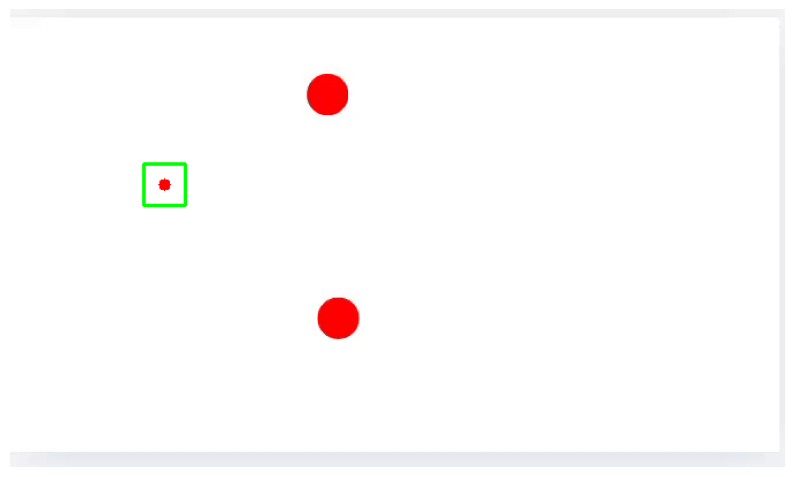

In [33]:
plt.figure(figsize=(10, 6))

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Since a video contains many frames I build a loop here.

In [45]:
import cv2
import numpy as np

# Video path
video_path = r"C:\Users\USER\Desktop\5th Semester\Robotics Self\OpenCV\videos\red_dot_motion.mp4"

# Open video
video = cv2.VideoCapture(video_path)

# Check whether video opened successfully
if not video.isOpened():
    print("Error: Could not open the video.")
    exit()

while True:

    # 1. Read a frame
    ret, frame = video.read()

    # Stop when the video ends
    if not ret:
        break

    # Get frame dimensions
    height, width = frame.shape[:2]

    # Image center
    image_center_x = width // 2
    image_center_y = height // 2

    # 2. Convert BGR → HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 3. Define red color ranges
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 100, 100])
    upper_red2 = np.array([179, 255, 255])

    # 4. Create red masks
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    mask = mask1 | mask2

    # 5. Find contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # 6. Find the largest red object
    if len(contours) > 0:

        largest_contour = max(
            contours,
            key=cv2.contourArea
        )

        area = cv2.contourArea(largest_contour)

        # Ignore small noise
        if area > 100:

            # 7. Bounding box
            x, y, w, h = cv2.boundingRect(largest_contour)

            # 8. Center of object
            center_x = x + w // 2
            center_y = y + h // 2

            # 9. Draw bounding box
            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            # 10. Draw center
            cv2.circle(
                frame,
                (center_x, center_y),
                5,
                (0, 0, 255),
                -1
            )

            # 11. Display center coordinates
            cv2.putText(
                frame,
                f"Center: ({center_x}, {center_y})",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2
            )

            # Display bounding box size
            cv2.putText(
                frame,
                f"Width: {w} Height: {h}",
                (x, y + h + 25),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2
            )

    # 12. Show frame
    cv2.imshow("Object Tracking", frame)

    # Press q to stop
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

# 13. Clean up
video.release()
cv2.destroyAllWindows()

### Here now I am trying to calculate the error from the center of image

In [42]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

video_path = r"videos/red_dot_motion.mp4"

video = cv2.VideoCapture(video_path)

ret, frame = video.read()

if ret:

    # Image size
    height, width = frame.shape[:2]

    # Image center
    image_center_x = width // 2
    image_center_y = height // 2

    # Convert BGR → HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Red ranges
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 100, 100])
    upper_red2 = np.array([180, 255, 255])

    # Create masks
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    mask = mask1 | mask2

    # Find contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) > 0:

        # Largest red object
        largest_contour = max(
            contours,
            key=cv2.contourArea
        )

        area = cv2.contourArea(largest_contour)

        if area > 100:

            # Bounding box
            x, y, w, h = cv2.boundingRect(largest_contour)

            # Object center
            center_x = x + w // 2
            center_y = y + h // 2

            # Calculate error
            error_x = center_x - image_center_x
            error_y = center_y - image_center_y
            Kp = 0.05

            control_x = Kp * error_x

            print("Error X:", error_x)
            print("Control X:", control_x)  
            # Bounding box
            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            # Object center
            cv2.circle(
                frame,
                (center_x, center_y),
                5,
                (0, 0, 255),
                -1
            )

            # Image center line
            cv2.line(
                frame,
                (image_center_x, 0),
                (image_center_x, height),
                (255, 0, 0),
                2
            )

            # Display error
            cv2.putText(
                frame,
                f"Error X: {error_x}",
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )

            print("Object center:", center_x, center_y)
            print("Image center:", image_center_x, image_center_y)
        

    # Convert BGR → RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

else:
    print("Could not read frame.")

video.release()

Could not read frame.


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video_path = r"C:\Users\USER\Desktop\5th Semester\Robotics Self\OpenCV\videos\red_dot_motion.mp4"

video = cv2.VideoCapture(video_path)

Kp = 0.05

errors = []
controls = []

while True:

    ret, frame = video.read()

    if not ret:
        break

    # Image dimensions
    height, width = frame.shape[:2]

    # Image center
    image_center_x = width // 2
    image_center_y = height // 2

    # Convert BGR → HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Red color ranges
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 100, 100])
    upper_red2 = np.array([180, 255, 255])

    # Create masks
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    mask = mask1 | mask2

    # Find contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # If an object was detected
    if len(contours) > 0:

        largest_contour = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(largest_contour)

        if area > 100:

            # Bounding box
            x, y, w, h = cv2.boundingRect(largest_contour)

            # Object center
            center_x = x + w // 2
            center_y = y + h // 2

            # Position error
            error_x = center_x - image_center_x

            # Proportional control
            control_x = Kp * error_x

            # Store values
            errors.append(error_x)
            controls.append(control_x)

video.release()

print("Number of detected frames:", len(errors))

Number of detected frames: 452


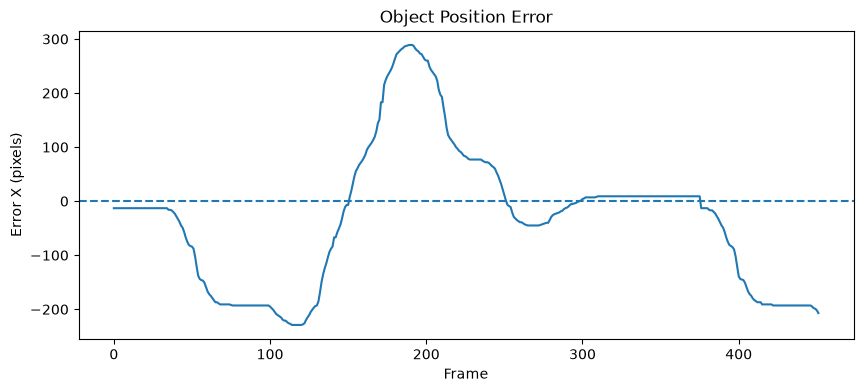

In [19]:
plt.figure(figsize=(10, 4))

plt.plot(errors)

plt.axhline(0, linestyle="--")

plt.xlabel("Frame")
plt.ylabel("Error X (pixels)")
plt.title("Object Position Error")

plt.show()

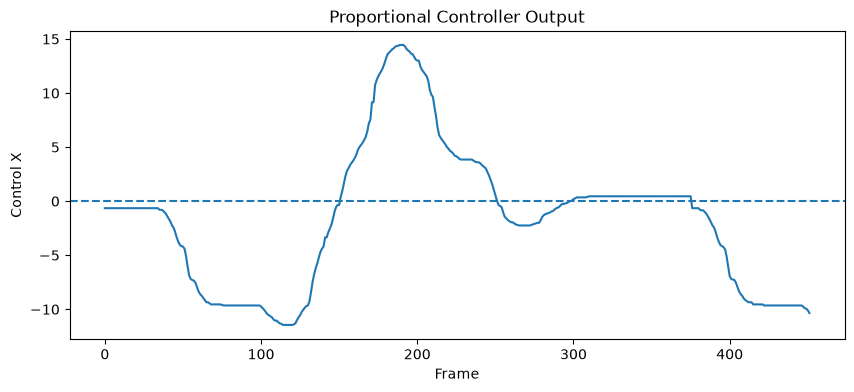

In [20]:
plt.figure(figsize=(10, 4))

plt.plot(controls)

plt.axhline(0, linestyle="--")

plt.xlabel("Frame")
plt.ylabel("Control X")
plt.title("Proportional Controller Output")

plt.show()

In [25]:
Kp = 0.2

position = -200
target = 0

positions = []

for i in range(50):

    error = target - position

    control = Kp * error

    position = position + control

    positions.append(position)

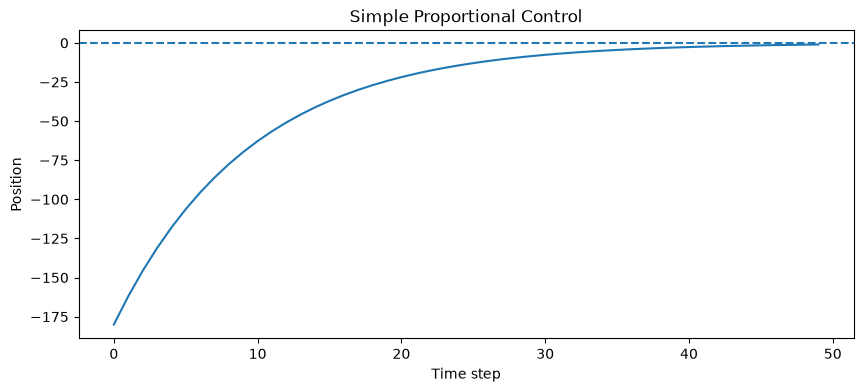

In [24]:
plt.figure(figsize=(10, 4))

plt.plot(positions)

plt.axhline(0, linestyle="--")

plt.xlabel("Time step")
plt.ylabel("Position")
plt.title("Simple Proportional Control")

plt.show()